# Projeto 2 — FUT AI

**Trainee:** Theo Ribeiro França

This notebook is your deliverable. Document your reasoning, iterations, and conclusions as you go — grading weights documentation quality alongside leaderboard score.


## 1. Load the data

MNIST ships with Keras. Nothing to change here.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"train: {x_train.shape}, dtype={x_train.dtype}, range=[{x_train.min()}, {x_train.max()}]")
print(f"test : {x_test.shape}, dtype={x_test.dtype}")

2026-04-29 15:15:49.897903: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-29 15:15:49.898548: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-29 15:15:49.901161: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-29 15:15:49.907140: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777486549.917042   15728 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777486549.91

train: (60000, 28, 28), dtype=uint8, range=[0, 255]
test : (10000, 28, 28), dtype=uint8


## 2. Build your model

Your model must:
- accept input shape `(28, 28)` with `uint8` values in `[0, 255]`
- bake any preprocessing (normalization, etc.) as layers inside the model
- produce output shape `(10,)`
- use only allowed layers (see `tools/contract.py` → `ALLOWED_LAYERS`)
- stay under 800 KB in total weights (trainable + non-trainable)

Document *why* you made each architectural choice — that's the whole point of this project.

In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Rescaling, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers


early_stopping = EarlyStopping(
    monitor='val_accuracy',  
    patience=10,           
    restore_best_weights=True,
)

model = Sequential([
    Dense(200, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(100, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(50, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(25, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(3, activation='softmax'),
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),  
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

/home/theo/AI/mnist-challenge-TheoRibeiroFranca-2/.venv/lib/python3.12/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-04-29 15:15:54.840264: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200)            │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 25)             │           100 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,185 (723.38 KB)

 Trainable params: 184,435 (720.45 KB)

 Non-trainable params: 750 (2.93 KB)

## 3. Train

Document your training decisions: optimizer, learning rate, batch size, epochs, callbacks, data augmentation, etc. Record what you tried and why.

In [ ]:
# TODO: train your model
import zipfile
with zipfile.ZipFile("validation-set.zip", "r") as z:
    z.extractall(".")

import tensorflow as tf

dataset = tf.keras.utils.image_dataset_from_directory(
    "validation-set/digits",
    image_size=(28, 28),
    color_mode="grayscale",
    batch_size=None, 
    label_mode="int",
    shuffle=False,
)

x_extra = []
y_extra = []
for img, label in dataset:
    x_extra.append(img.numpy().squeeze())  
    y_extra.append(label.numpy())

import numpy as np
x_extra = np.array(x_extra)
y_extra = np.array(y_extra)

x_train_inv = 255 - x_train
x_test_inv = 255 - x_test

x_extra_rep_fase1 = np.tile(x_extra, (10, 1, 1)) 
y_extra_rep_fase1 = np.tile(y_extra, 10)

x_train_final = np.concatenate([x_train_inv, x_extra, x_sint], axis=0)
y_train_final = np.concatenate([y_train, y_extra, y_sint], axis=0)


history_fase1 = model.fit(
    x_train_final,
    y_train_final,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stopping],
)

x_extra_rep2 = np.tile(x_extra, (10, 1, 1))  
y_extra_rep2 = np.tile(y_extra, 10)

model.compile(
    optimizer=Adam(learning_rate=0.00005),  
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history_fase2 = model.fit(
    x_extra_rep2,
    y_extra_rep2,
    epochs=40,
    batch_size=16,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)],
)

Found 320 files belonging to 10 classes.
Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9660 - loss: 0.1077 - val_accuracy: 0.8338 - val_loss: 1.2811
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9692 - loss: 0.0965 - val_accuracy: 0.8353 - val_loss: 1.2634
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9736 - loss: 0.0868 - val_accuracy: 0.8353 - val_loss: 1.2526
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9750 - loss: 0.0821 - val_accuracy: 0.8354 - val_loss: 1.2488
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9748 - loss: 0.0812 - val_accuracy: 0.8356 - val_loss: 1.2479
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9761 - loss: 0.0757 - val_accuracy: 0.8357 - val_loss: 1.2479
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9764 - loss: 0.0745 - val_accuracy: 0.8358 - val_loss: 1.2459
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accu

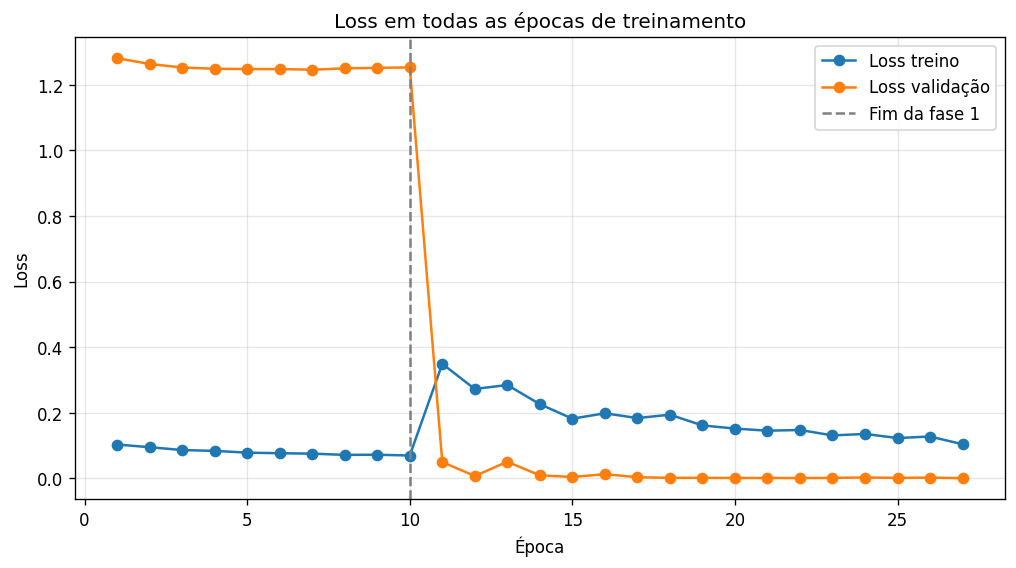

In [ ]:
import os
from io import BytesIO

os.environ['MPLBACKEND'] = 'agg'
os.environ['MPLCONFIGDIR'] = '/tmp/matplotlib-config'

from IPython.display import Image, display
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.figure import Figure

loss_treino = history_fase1.history['loss'] + history_fase2.history['loss']
loss_validacao = history_fase1.history['val_loss'] + history_fase2.history['val_loss']
epocas = range(1, len(loss_treino) + 1)
fim_fase1 = len(history_fase1.history['loss'])

fig = Figure(figsize=(10, 5))
FigureCanvasAgg(fig)
ax = fig.subplots()
ax.plot(epocas, loss_treino, marker='o', label='Loss treino')
ax.plot(epocas, loss_validacao, marker='o', label='Loss validação')
ax.axvline(fim_fase1, color='gray', linestyle='--', label='Fim da fase 1')
ax.set_title('Loss em todas as épocas de treinamento')
ax.set_xlabel('Época')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

buffer = BytesIO()
fig.savefig(buffer, format='png', bbox_inches='tight', dpi=120)
display(Image(data=buffer.getvalue()))

## 4. Evaluate locally

The public MNIST test set is a proxy for the private validation set the server uses. Use it to iterate.

In [ ]:
# TODO: evaluate
_, train_accuracy = model.evaluate(x_train_final, y_train_final, verbose=0)
test_loss, test_accuracy = model.evaluate(x_test_inv, y_test, verbose=0)
print(f"Acurácia no conjunto de treino: {train_accuracy * 100:.2f}%")
print(f"Acurácia no conjunto de teste: {test_accuracy * 100:.2f}%")

Acurácia no conjunto de treino: 93.81%
Acurácia no conjunto de teste: 95.78%
